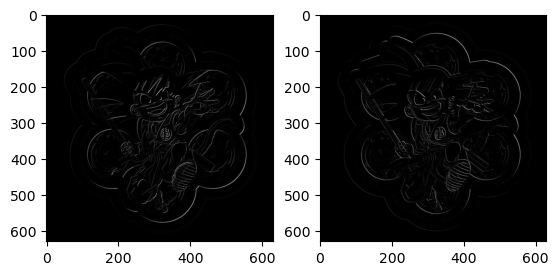

In [12]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread('goku.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
robertx = np.array ([[-1,0], [0,1]])
roberty = np.array ([[0,1], [-1,0]])
robx_img = cv2.filter2D(gray, -1, robertx)
roby_img = cv2.filter2D(gray, -1, roberty)
rob_grad = np.sqrt(robx_img**2 + roby_img**2)
rob_grad_dir = np.arctan2(roby_img, robx_img) * (180 / np.pi)

# prewitt

prewittx = np.array ([[-1,0,1], [-1,0,1], [-1,0,1]])
prewitty = np.array ([[1,1,1], [0,0,0], [-1,-1,-1]])
prex_img = cv2.filter2D(gray, -1, prewittx)
prey_img = cv2.filter2D(gray, -1, prewitty)
prewitt_mag = np.sqrt(prex_img**2 + prey_img**2)
preww_dir = np.arctan2(prex_img, prey_img)

# solbel

solbel_x = np.array ([[-1,0,1], [-2,0,2], [-1,0,1]])
solbel_y = np.array ([[1,2,1], [0,0,0], [-1,-2,-1]])
solbelx_img = cv2.filter2D(gray, -1, solbel_x)
solbely_img = cv2.filter2D(gray, -1, solbel_y)
solbel_mag = np.sqrt(solbelx_img**2 + solbely_img**2)
solbel_dir = np.arctan2(solbely_img, solbelx_img)

cany_img = cv2.Canny(gray, 100, 200)

plt .figure(figsize=(10, 10))
plt.subplot(331)
plt.imshow(robx_img, cmap='gray')
plt.subplot(332)
plt.imshow(roby_img, cmap='gray')


SOBEL

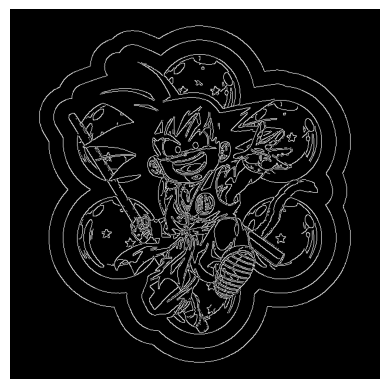

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def filtro_sobel(img, kernel_size=3, umbral=30):
    img_gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    #para mejorar la deteccion filtro gauss\
    img_gris = cv2.GaussianBlur(img_gris,(3,3),0)

    g_x = cv2.Sobel(img_gris, cv2.CV_64F, 1, 0, ksize=3)
    g_y = cv2.Sobel(img_gris, cv2.CV_64F, 0, 1, ksize=3)

    #mag = np.sqrt(np.square(g_x) + np.square(g_y))
    mag = np.sqrt(g_x**2 + g_y**2)
    mag = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)
    _,border = cv2.threshold(mag, umbral, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    #Operacion MORPH Donde Unimos Bordes Rotos
    kernel_n = np.ones((2,2), np.uint8)
    bordes = cv2.morphologyEx(border, cv2.MORPH_CLOSE, kernel_n)
    return bordes

img = cv2.imread('goku.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
bordes = cv2.Canny(gris, 100, 200)

plt.imshow(bordes, cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt